In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
import sys
sys.path.append('../models')

df           = pd.read_parquet('../data/features/train_features.parquet')
feature_cols = joblib.load('../models/saved/feature_cols.joblib')
scaler       = joblib.load('../models/saved/scaler.joblib')
xgb_model    = joblib.load('../models/saved/xgboost.joblib')
rf_model     = joblib.load('../models/saved/random_forest.joblib')
iso_forest   = joblib.load('../models/saved/isolation_forest.joblib')

X = df[feature_cols]
y = df['RUL_capped']

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_test_scaled = scaler.transform(X_test)

print(f"Models loaded ✅")
print(f"Test samples: {len(X_test)}")

Models loaded ✅
Test samples: 32072


In [3]:
# XGBoost
start = time.time()
xgb_preds = xgb_model.predict(X_test)
xgb_latency = (time.time() - start) * 1000

# Random Forest
start = time.time()
rf_preds = rf_model.predict(X_test)
rf_latency = (time.time() - start) * 1000

# Isolation Forest
start = time.time()
iso_scores = iso_forest.decision_function(X_test_scaled)
iso_latency = (time.time() - start) * 1000
iso_preds = (iso_scores - iso_scores.min()) / (
    iso_scores.max() - iso_scores.min()) * 125

print("All predictions done ✅")

All predictions done ✅


In [6]:
def get_metrics(name, y_true, y_pred, latency):
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)
    diff  = y_pred - y_true
    nasa  = np.sum(np.where(diff < 0,
                            np.exp(-diff/13)-1,
                            np.exp(diff/10)-1))
    return {
        'Model'        : name,
        'RMSE'         : round(rmse, 3),
        'MAE'          : round(mae, 3),
        'R2 Score'     : round(r2, 3),
        'NASA Score'   : round(nasa, 0),
        'Latency (ms)' : round(latency, 1)
    }

results = pd.DataFrame([
    get_metrics('XGBoost',          y_test, xgb_preds, xgb_latency),
    get_metrics('Random Forest',    y_test, rf_preds,  rf_latency),
    get_metrics('Isolation Forest', y_test, iso_preds, iso_latency),
])

# Style the table
styled = results.style\
    .highlight_min(subset=['RMSE','MAE','NASA Score'], color='green')\
    .highlight_max(subset=['R2 Score'], color='green')\
    .highlight_max(subset=['RMSE','MAE'], color="#e00808")\
    .set_caption('SensorMind — Model Comparison Table')\
    .format({'RMSE':'{:.3f}','MAE':'{:.3f}',
             'R2 Score':'{:.3f}','NASA Score':'{:,.0f}',
             'Latency (ms)':'{:.1f}'})

print("Model Comparison Table:")
display(styled)

Model Comparison Table:


,Model,RMSE,MAE,R2 Score,NASA Score,Latency (ms)
0,XGBoost,17.356,12.186,0.822,"359,312",147.0
1,Random Forest,19.496,14.982,0.776,"558,669",236.3
2,Isolation Forest,45.221,37.301,-0.205,"26,948,396",357.7


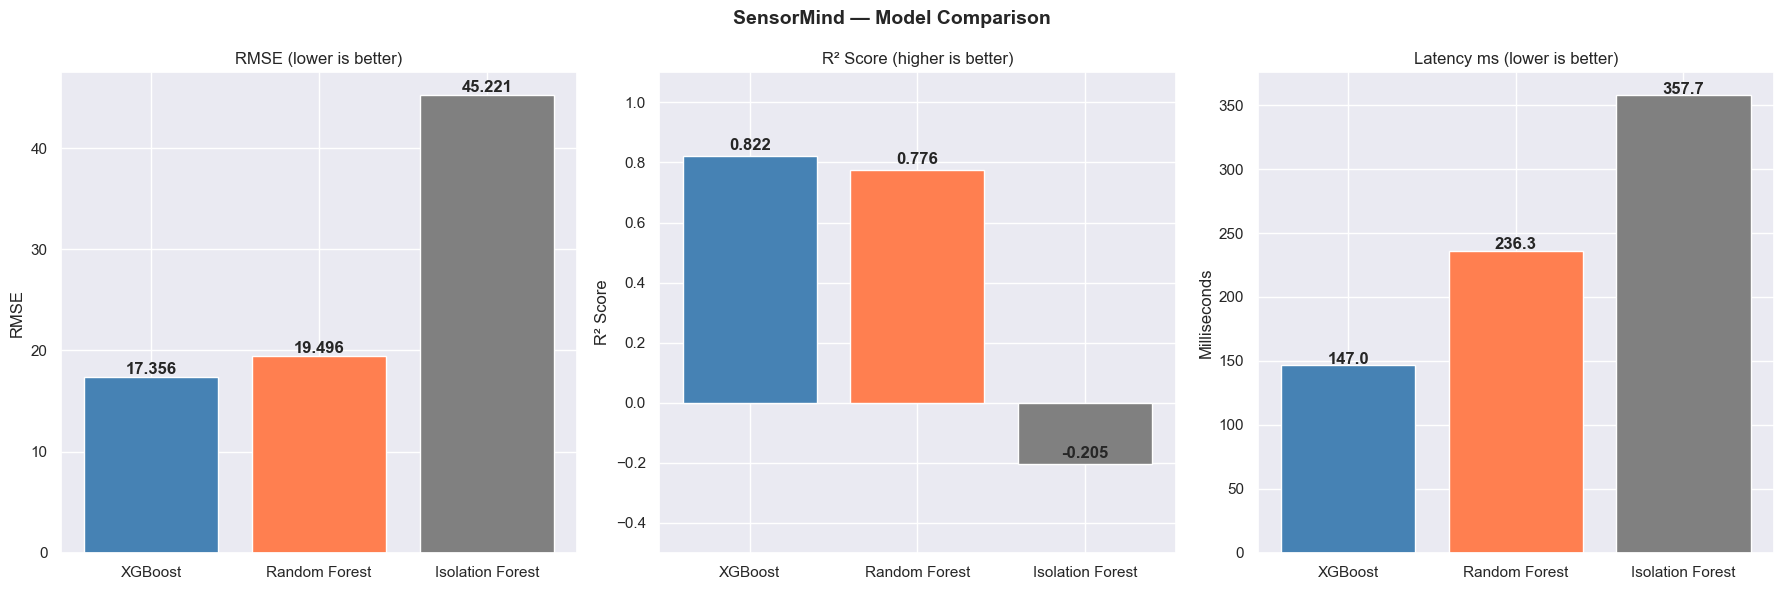

Plot 17 saved ✅


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['steelblue', 'coral', 'gray']
models = results['Model'].tolist()

# RMSE
axes[0].bar(models, results['RMSE'], color=colors, edgecolor='white')
axes[0].set_title('RMSE (lower is better)')
axes[0].set_ylabel('RMSE')
for i, v in enumerate(results['RMSE']):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# R2 Score
axes[1].bar(models, results['R2 Score'], color=colors, edgecolor='white')
axes[1].set_title('R² Score (higher is better)')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(-0.5, 1.1)
for i, v in enumerate(results['R2 Score']):
    axes[1].text(i, v + 0.02, str(v), ha='center', fontweight='bold')

# Latency
axes[2].bar(models, results['Latency (ms)'], color=colors, edgecolor='white')
axes[2].set_title('Latency ms (lower is better)')
axes[2].set_ylabel('Milliseconds')
for i, v in enumerate(results['Latency (ms)']):
    axes[2].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.suptitle('SensorMind — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot17_model_comparison.png', dpi=150)
plt.show()
print("Plot 17 saved ✅")

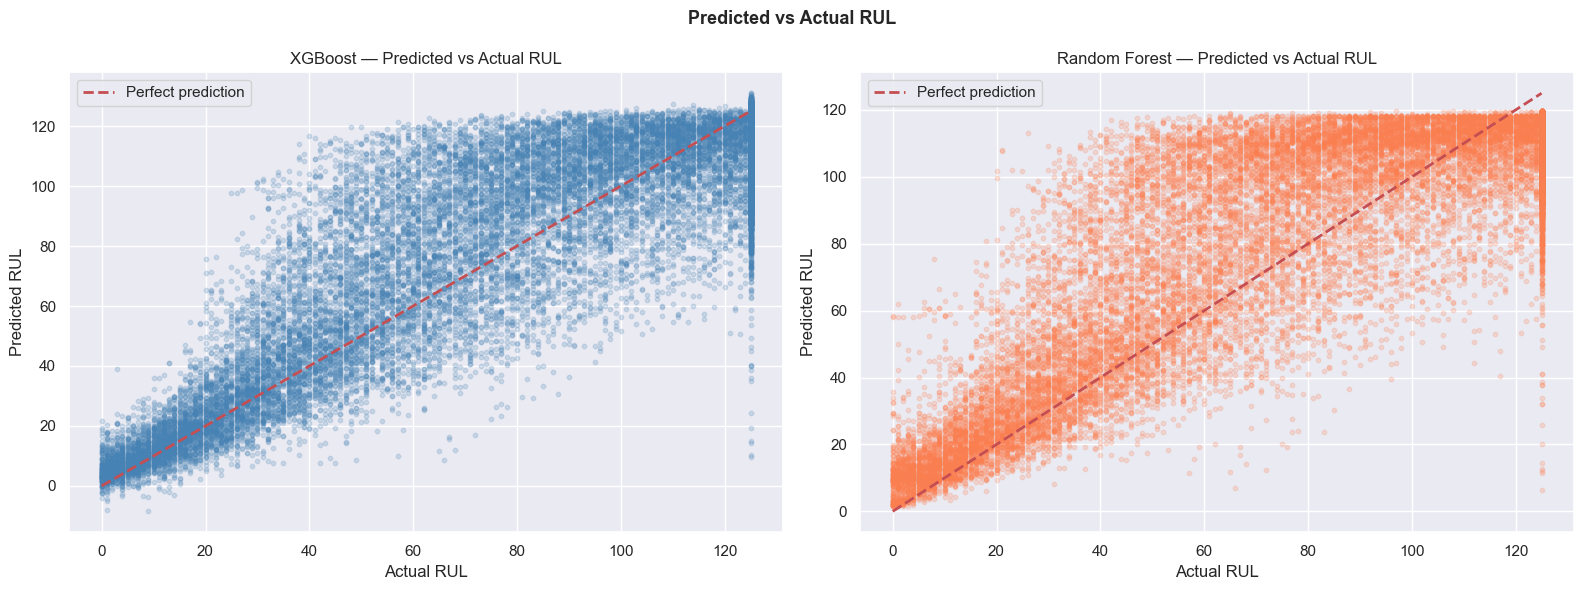

Plot 18 saved ✅


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, name, color in zip(
    axes,
    [xgb_preds, rf_preds],
    ['XGBoost', 'Random Forest'],
    ['steelblue', 'coral']
):
    ax.scatter(y_test, preds, alpha=0.2, color=color, s=10)
    ax.plot([0, 125], [0, 125], 'r--', linewidth=2, label='Perfect prediction')
    ax.set_title(f'{name} — Predicted vs Actual RUL')
    ax.set_xlabel('Actual RUL')
    ax.set_ylabel('Predicted RUL')
    ax.legend()

plt.suptitle('Predicted vs Actual RUL', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot18_predicted_vs_actual.png', dpi=150)
plt.show()
print("Plot 18 saved ✅")

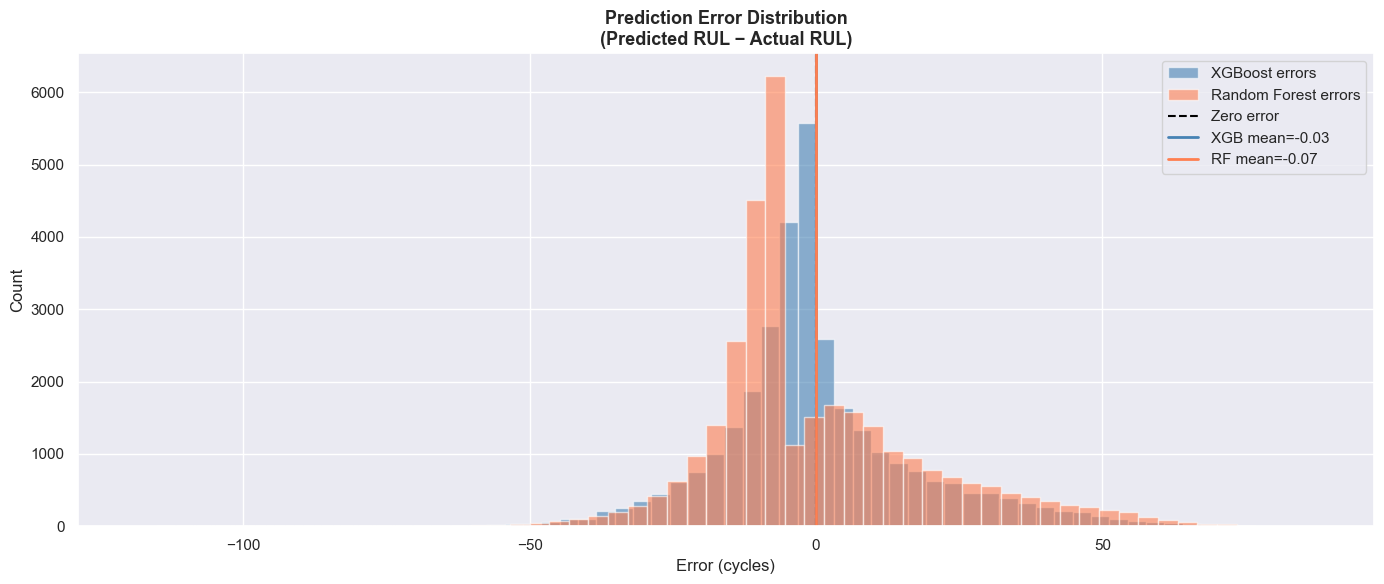

Plot 19 saved ✅


In [9]:
xgb_errors = xgb_preds - y_test
rf_errors  = rf_preds  - y_test

plt.figure(figsize=(14, 6))
plt.hist(xgb_errors, bins=60, alpha=0.6,
         color='steelblue', label='XGBoost errors', edgecolor='white')
plt.hist(rf_errors,  bins=60, alpha=0.6,
         color='coral',     label='Random Forest errors', edgecolor='white')
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--', label='Zero error')
plt.axvline(x=xgb_errors.mean(), color='steelblue',
            linewidth=2, linestyle='-', label=f'XGB mean={xgb_errors.mean():.2f}')
plt.axvline(x=rf_errors.mean(),  color='coral',
            linewidth=2, linestyle='-', label=f'RF mean={rf_errors.mean():.2f}')
plt.title('Prediction Error Distribution\n(Predicted RUL − Actual RUL)',
          fontsize=13, fontweight='bold')
plt.xlabel('Error (cycles)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/plot19_error_distribution.png', dpi=150)
plt.show()
print("Plot 19 saved ✅")

In [10]:
best = results.loc[results['RMSE'].idxmin()]

print("=" * 55)
print("        WEEK 2 COMPLETE — SENSORMIND ML PIPELINE")
print("=" * 55)
print(f"""
  Best Model  : {best['Model']}
  RMSE        : {best['RMSE']} cycles
  MAE         : {best['MAE']} cycles
  R2 Score    : {best['R2 Score']}

  Interpretation:
  → Model predicts RUL within ±{best['MAE']} cycles on average
  → Explains {best['R2 Score']*100:.1f}% of engine degradation variance
  → Top failure sensors: sensor_13, sensor_15, sensor_11

  Production decision:
  → XGBoost used for /predict endpoint (best accuracy)
  → Isolation Forest used for anomaly flagging
  → SHAP used for /explain endpoint
""")
print("=" * 55)
print("Week 2 deliverable: 3 trained models + evaluation ✅")

        WEEK 2 COMPLETE — SENSORMIND ML PIPELINE

  Best Model  : XGBoost
  RMSE        : 17.356 cycles
  MAE         : 12.186 cycles
  R2 Score    : 0.822

  Interpretation:
  → Model predicts RUL within ±12.186 cycles on average
  → Explains 82.2% of engine degradation variance
  → Top failure sensors: sensor_13, sensor_15, sensor_11

  Production decision:
  → XGBoost used for /predict endpoint (best accuracy)
  → Isolation Forest used for anomaly flagging
  → SHAP used for /explain endpoint

Week 2 deliverable: 3 trained models + evaluation ✅
